# 4.1. Results: Main Figures

### 📘 Overview

This notebook generates a summary of DILI risk predictions, including visualizations for key figures in the publication.

**Input**: 
* Predicted DILI risk & true labels
* DILI safety margins

**Output**: 
* **Figures 2-5**
* **Suppl. Figures S6-S8**
* **Results summary table**

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import dilimap as dmap

In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
dmap.logging.print_version()

Running dilimap 1.0.2 (python 3.10.16) on 2025-06-29 15:30.


## 1. Re-run Validation

In [3]:
dmap.s3.login()

In [4]:
model = dmap.models.ToxPredictor()

Package: s3://dilimap/public/models. Top hash: b119d5a238
Package: s3://dilimap/public/data. Top hash: e5bf3de9d2


In [5]:
adata_val = dmap.datasets.DILImap_validation_data()

Package: s3://dilimap/public/data. Top hash: e5bf3de9d2


In [6]:
dmap.utils.map_dili_labels_and_cmax(adata_val)

Package: s3://dilimap/public/data. Top hash: e5bf3de9d2
Package: s3://dilimap/public/data. Top hash: e5bf3de9d2
Package: s3://dilimap/public/data. Top hash: e5bf3de9d2


In [7]:
df_res_margins_val = model.compute_safety_margin(adata_val)

283 out of 469 features in your data are not present in the training data. These features will not impact predictions. You can access the features available in the training data via `model.features`.


## 2. Combine cross-validation and validation results

In [8]:
df_res_all = pd.concat(
    [
        model.cross_val_results.assign(Batch='cross-validation'),
        df_res_margins_val.assign(Batch='validation'),
    ],
    ignore_index=False,
)

In [9]:
dmap.utils.map_dili_labels_and_cmax(
    df_res_all,
    labels=['DILIrank', 'label_section', 'livertox_score', 'DILI_label'],
    insert_at_front=True,
)

Package: s3://dilimap/public/data. Top hash: e5bf3de9d2


In [10]:
true_label = np.where(
    df_res_all['DILI_label'].isin(
        ['DILI (withdrawn)', 'DILI (known)', 'DILI (likely)']
    ),
    '+',
    np.where(df_res_all['DILI_label'].isin(['No DILI']), '-', ''),
)

df_res_all.insert(loc=4, column='True_label', value=true_label)

In [11]:
df_res_all = df_res_all.sort_values(
    ['Batch', 'True_label', 'DILI_label', 'MOS_ToxPredictor'], ascending=False
)

In [12]:
# Copy test fold assignments and simplify index to compound names
df_testfolds = model.test_fold_assignments.copy()
df_testfolds.index = df_testfolds.index.str.extract(r'^([^_]+)')[0]
df_testfolds = df_testfolds.groupby(df_testfolds.index).first()

# Map test folds to result index
test_folds = df_res_all.index.map(df_testfolds['test_fold'])

# Assign fallback fold labels for missing values
df_res_all['test_fold'] = np.where(
    test_folds.isna() & (df_res_all['Batch'] == 'validation'),
    'val',
    np.where(test_folds.isna(), 'test', test_folds.astype('Int64').astype(str)),
)

## 3. DILI label summary stats

In [13]:
df_tmp = df_res_all.copy()

df_tmp = df_tmp[~df_tmp.index.duplicated()]

In [14]:
df_tmp['DILIrank'] = np.where(
    (df_tmp['DILI_label'] == 'DILI (withdrawn)')
    & (df_tmp['DILIrank'] == 'Most-DILI-Concern'),
    'Withdrawn Most-DILI-Concern',
    np.where(
        df_tmp['DILI_label'] == 'DILI (withdrawn)',
        'Clinical failures',
        df_tmp['DILIrank'],
    ),
)

df_tmp['DILIrank'] = df_tmp['DILIrank'].replace(np.nan, '')
df_tmp['livertox_score'] = df_tmp['livertox_score'].replace(np.nan, '')

In [15]:
df_ct = pd.crosstab(
    df_tmp['DILIrank'].values,
    df_tmp['livertox_score'].values,
    df_tmp['DILI_label'].values,
    aggfunc=set,
)

df_ct.index.name = None
df_ct.columns.name = None

df_ct = df_ct.loc[
    [
        'Clinical failures',
        'Withdrawn Most-DILI-Concern',
        'Most-DILI-Concern',
        'Less-DILI-Concern',
        'Ambiguous DILI-concern',
        'No-DILI-Concern',
    ]
]

df_ct = df_ct[['A', 'A [HD]', 'B', '', 'C', 'D', 'E', 'E*']]

df_ct

,A,A [HD],B,,C,D,E,E*
Clinical failures,NaN,NaN,NaN,{DILI (withdrawn)},NaN,NaN,NaN,NaN
Withdrawn Most-DILI-Concern,{DILI (withdrawn)},NaN,NaN,{DILI (withdrawn)},{DILI (withdrawn)},NaN,NaN,NaN
Most-DILI-Concern,{DILI (known)},{DILI (known)},{DILI (likely)},{DILI (likely)},{DILI (likely)},{DILI (likely)},NaN,NaN
Less-DILI-Concern,{DILI (likely)},{DILI (likely)},{DILI (likely)},{DILI (few cases)},{DILI (few cases)},{DILI (few cases)},{No DILI (unlikely)},{No DILI (unlikely)}
Ambiguous DILI-concern,NaN,NaN,NaN,NaN,NaN,NaN,{No DILI},NaN
No-DILI-Concern,NaN,NaN,{DILI (likely)},{No DILI},{No DILI},{No DILI},{No DILI},{No DILI}


In [16]:
df_ct = pd.crosstab(
    df_tmp['DILIrank'].values,
    df_tmp['livertox_score'].values,
)

df_ct.index.name = None
df_ct.columns.name = None

df_ct = df_ct.loc[
    [
        'Clinical failures',
        'Withdrawn Most-DILI-Concern',
        'Most-DILI-Concern',
        'Less-DILI-Concern',
        'Ambiguous DILI-concern',
        'No-DILI-Concern',
    ]
]

df_ct = df_ct[['A', 'A [HD]', 'B', '', 'C', 'D', 'E', 'E*']]

df_ct

,A,A [HD],B,,C,D,E,E*
Clinical failures,0,0,0,5,0,0,0,0
Withdrawn Most-DILI-Concern,4,0,0,17,1,0,0,0
Most-DILI-Concern,27,1,16,3,18,7,0,0
Less-DILI-Concern,9,2,28,5,34,27,10,7
Ambiguous DILI-concern,0,0,0,0,0,0,1,0
No-DILI-Concern,0,0,1,14,1,3,37,7


In [17]:
df_res_all[
    (df_res_all['DILI_label'] == 'DILI (withdrawn)')
    & (df_res_all['livertox_score'] == 'C')
]

,DILIrank,label_section,livertox_score,DILI_label,True_label,Cmax_uM,First_DILI_uM,MOS_Cytotoxicity,MOS_ToxPredictor,Primary_DILI_driver,Classification,Batch,test_fold
compound_name,,,,,,,,,,,,,
Tolcapone,Most-DILI-Concern,Box warning,C,DILI (withdrawn),+,37.693524,3.3,1.0,1.0,Transcriptomics,+,validation,val


## 4. Sensitivity / Specificity

In [18]:
df_res_cv = df_res_all[df_res_all['Batch'] == 'cross-validation']
df_res_val = df_res_all[df_res_all['Batch'] == 'validation']

df_res_dict = {
    'Cross-val & Validation': df_res_all,
    'Cross-validation': df_res_cv,
    'Validation': df_res_val,
}

In [19]:
print('# Compounds:', len(df_res_all))

# Compounds: 300


In [20]:
df_res_cv['DILI_label'].value_counts()

DILI_label
DILI (likely)         73
DILI (few cases)      69
No DILI               52
DILI (known)          25
No DILI (unlikely)    17
DILI (withdrawn)      13
Name: count, dtype: int64

In [21]:
df_res_cv['DILI_label'].str.startswith('DILI').value_counts()

DILI_label
True     180
False     69
Name: count, dtype: int64

In [22]:
df_res_val['True_label'].value_counts()

True_label
+    33
-    14
      4
Name: count, dtype: int64

In [25]:
from sklearn.metrics import confusion_matrix

for batch, df_tmp in df_res_dict.items():
    results = []

    df_res_DILI = df_tmp[
        df_tmp['DILI_label'].isin(
            ['DILI (withdrawn)', 'DILI (known)', 'DILI (likely)', 'No DILI']
        )
    ]
    df_res_iDILI = df_tmp[df_tmp['DILI_label'].isin(['DILI (few cases)'])]

    y_preds_strategies = [
        'Cmax_uM > 10',
        'MOS_Cytotoxicity < 120',
        'MOS_ToxPredictor < 80',
    ]

    for y_strat in y_preds_strategies:
        y_key, thresh = y_strat.split(' > ') if '>' in y_strat else y_strat.split(' < ')

        y_pred = df_res_DILI[y_key]
        y_true = ~df_res_DILI['DILI_label'].isin(['No DILI'])
        thresh = float(thresh)

        y_pred_bin = y_pred < thresh if '<' in y_strat else y_pred > thresh
        y_pred_bin_C = (
            df_res_iDILI[y_key] < thresh
            if '<' in y_strat
            else df_res_iDILI[y_key] > thresh
        )

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_bin).ravel()

        sensitivity = tp / (tp + fn) * 100
        specificity = tn / (tn + fp) * 100
        idiosyncratic_dili = np.mean(y_pred_bin_C) * 100

        # Append results to the list
        results.append(
            {
                'Strategy': y_strat,
                'Sensitivity': f'{int(sensitivity)}% ({tp}/{(tp + fn)})',
                'Specificity': f'{int(specificity)}% ({tn}/{(tn + fp)})',
                'Idiosyncratic DILI': f'{int(idiosyncratic_dili)}% ({sum(y_pred_bin_C)}/{len(y_pred_bin_C)})',
            }
        )

    # Convert the results list into a DataFrame
    df_results = pd.DataFrame(results)
    df_results = df_results.set_index('Strategy')

    print(f'\n{batch}')
    display(df_results)


Cross-val & Validation


,Sensitivity,Specificity,Idiosyncratic DILI
Strategy,,,
Cmax_uM > 10,38% (55/144),98% (65/66),16% (12/71)
MOS_Cytotoxicity < 120,34% (50/144),93% (62/66),16% (12/71)
MOS_ToxPredictor < 80,76% (110/144),87% (58/66),43% (31/71)



Cross-validation


,Sensitivity,Specificity,Idiosyncratic DILI
Strategy,,,
Cmax_uM > 10,31% (35/111),98% (51/52),17% (12/69)
MOS_Cytotoxicity < 120,36% (41/111),92% (48/52),17% (12/69)
MOS_ToxPredictor < 80,72% (81/111),84% (44/52),43% (30/69)



Validation


,Sensitivity,Specificity,Idiosyncratic DILI
Strategy,,,
Cmax_uM > 10,60% (20/33),100% (14/14),0% (0/2)
MOS_Cytotoxicity < 120,27% (9/33),100% (14/14),0% (0/2)
MOS_ToxPredictor < 80,87% (29/33),100% (14/14),50% (1/2)


In [26]:
from sklearn.metrics import confusion_matrix

for batch, df_tmp in df_res_dict.items():
    results = []

    df_res_DILI = df_tmp[
        df_tmp['DILI_label'].isin(
            ['DILI (withdrawn)', 'DILI (known)', 'DILI (likely)', 'No DILI']
        )
    ]
    df_res_iDILI = df_tmp[df_tmp['DILI_label'].isin(['DILI (few cases)'])]

    y_preds_strategies = [
        'Cmax_uM > 25',
        'MOS_Cytotoxicity < 80',
        'MOS_Cytotoxicity < 120',
        'MOS_ToxPredictor < 80',
    ]

    for y_strat in y_preds_strategies:
        # Evaluate strategy expression for both DILI and iDILI
        y_pred_bin = df_res_DILI.eval(y_strat)
        y_pred_bin_C = df_res_iDILI.eval(y_strat)

        y_true = ~df_res_DILI['DILI_label'].isin(['No DILI'])

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_bin).ravel()

        sensitivity = tp / (tp + fn) * 100
        specificity = tn / (tn + fp) * 100
        idiosyncratic_dili = np.mean(y_pred_bin_C) * 100

        results.append(
            {
                'Strategy': y_strat,
                'Sensitivity': f'{int(sensitivity)}% ({tp}/{tp + fn})',
                'Specificity': f'{int(specificity)}% ({tn}/{tn + fp})',
                'Idiosyncratic DILI': f'{int(idiosyncratic_dili)}% ({sum(y_pred_bin_C)}/{len(y_pred_bin_C)})',
            }
        )

    df_results = pd.DataFrame(results).set_index('Strategy')
    print(f'\n{batch}')
    display(df_results)


Cross-val & Validation


,Sensitivity,Specificity,Idiosyncratic DILI
Strategy,,,
Cmax_uM > 25,20% (29/144),98% (65/66),7% (5/71)
MOS_Cytotoxicity < 80,29% (42/144),95% (63/66),12% (9/71)
MOS_Cytotoxicity < 120,34% (50/144),93% (62/66),16% (12/71)
MOS_ToxPredictor < 80,76% (110/144),87% (58/66),43% (31/71)



Cross-validation


,Sensitivity,Specificity,Idiosyncratic DILI
Strategy,,,
Cmax_uM > 25,18% (21/111),98% (51/52),7% (5/69)
MOS_Cytotoxicity < 80,30% (34/111),94% (49/52),13% (9/69)
MOS_Cytotoxicity < 120,36% (41/111),92% (48/52),17% (12/69)
MOS_ToxPredictor < 80,72% (81/111),84% (44/52),43% (30/69)



Validation


,Sensitivity,Specificity,Idiosyncratic DILI
Strategy,,,
Cmax_uM > 25,24% (8/33),100% (14/14),0% (0/2)
MOS_Cytotoxicity < 80,24% (8/33),100% (14/14),0% (0/2)
MOS_Cytotoxicity < 120,27% (9/33),100% (14/14),0% (0/2)
MOS_ToxPredictor < 80,87% (29/33),100% (14/14),50% (1/2)


In [27]:
df_res_dict['Validation']

,DILIrank,label_section,livertox_score,DILI_label,True_label,Cmax_uM,First_DILI_uM,MOS_Cytotoxicity,MOS_ToxPredictor,Primary_DILI_driver,Classification,Batch,test_fold
compound_name,,,,,,,,,,,,,
Almotriptan,No-DILI-Concern,No match,E,No DILI,-,0.182730,NaN,300.000000,300.000000,none,-,validation,val
Bethanechol,No-DILI-Concern,No match,E,No DILI,-,1.612703,NaN,300.000000,300.000000,none,-,validation,val
Bisacodyl,No-DILI-Concern,No match,E,No DILI,-,0.150000,NaN,300.000000,300.000000,none,-,validation,val
Brompheniramine,No-DILI-Concern,No match,E,No DILI,-,0.036336,NaN,300.000000,300.000000,none,-,validation,val
Cinacalcet,No-DILI-Concern,No match,NaN,No DILI,-,0.083657,NaN,300.000000,300.000000,none,-,validation,val
Frovatriptan,No-DILI-Concern,No match,E,No DILI,-,0.032880,333.000000,300.000000,300.000000,none,-,validation,val
Isoxsuprine,No-DILI-Concern,No match,NaN,No DILI,-,0.365529,NaN,300.000000,300.000000,none,-,validation,val
Lubiprostone,No-DILI-Concern,No match,E,No DILI,-,0.000106,NaN,300.000000,300.000000,none,-,validation,val
Mecamylamine,No-DILI-Concern,No match,NaN,No DILI,-,0.110775,500.000000,300.000000,300.000000,none,-,validation,val


## 5. Boxplots (consensus DILI labels)

In [28]:
def transparent_figure(nrows=1, ncols=1, figsize=(4, 2.5), dpi=120):
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # transparent background
    fig.patch.set_alpha(0)
    ax.set_facecolor('none')
    return fig, ax

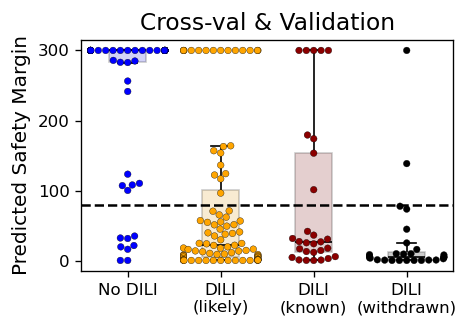

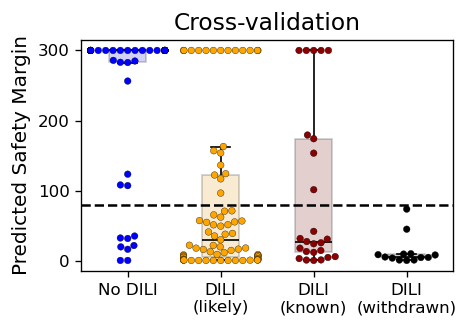

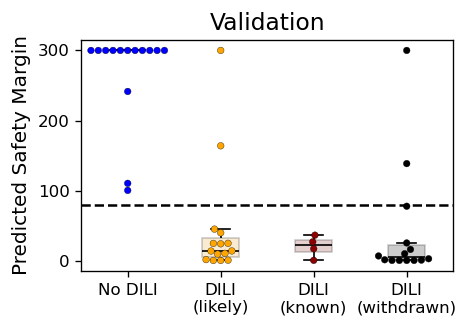

In [29]:
for k, df in df_res_dict.items():
    fig, ax = transparent_figure()

    hue_order = ['No DILI', 'DILI (likely)', 'DILI (known)', 'DILI (withdrawn)']
    dmap.pl.boxplot_with_swarm(
        df,
        x='DILI_label',
        y='MOS_ToxPredictor',
        title=k,
        box_width=0.4,
        swarm_size=4,
        hue_order=hue_order,
        palette=['blue', 'orange', 'darkred', 'k'],
        axhline=80,
        ylabel='Predicted Safety Margin',
        xlabel='',
        show_legend=False,
    )

## Boxplots (DILIrank labels)

/opt/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 50.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 32.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 25.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


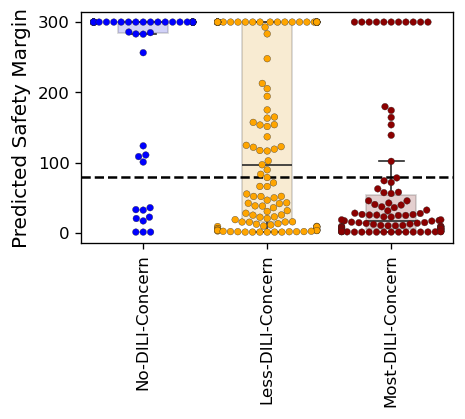

In [30]:
fig, ax = transparent_figure()

hue_order = ['No-DILI-Concern', 'Less-DILI-Concern', 'Most-DILI-Concern']
dmap.pl.boxplot_with_swarm(
    df_res_all[df_res_all['DILIrank'].isin(hue_order)],
    x='DILIrank',
    y='MOS_ToxPredictor',
    box_width=0.4,
    swarm_size=4,
    hue_order=hue_order,
    palette=['blue', 'orange', 'darkred'],
    axhline=80,
    ylabel='Predicted Safety Margin',
    xlabel='',
    show_legend=False,
    show=False,
)

plt.xticks(rotation=90)
plt.show()

/opt/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 53.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 40.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 27.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 5.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


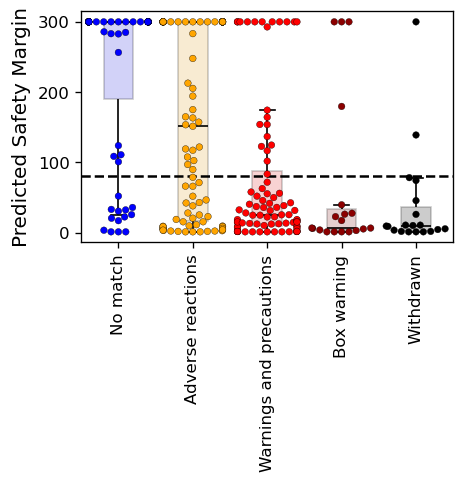

In [31]:
fig, ax = transparent_figure()

hue_order = [
    'No match',
    'Adverse reactions',
    'Warnings and precautions',
    'Box warning',
    'Withdrawn',
]
dmap.pl.boxplot_with_swarm(
    df_res_all,
    x='label_section',
    y='MOS_ToxPredictor',
    box_width=0.4,
    swarm_size=4,
    hue_order=hue_order,
    palette=['blue', 'orange', 'red', 'darkred', 'black'],
    axhline=80,
    ylabel='Predicted Safety Margin',
    xlabel='',
    show_legend=False,
    show=False,
)

plt.xticks(rotation=90)
plt.show()

## 6. Boxplots (Cytotoxicity & Cmax)

/opt/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 74.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 47.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 20.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 18.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


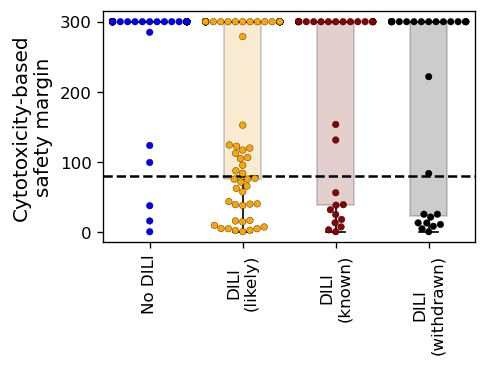

In [32]:
fig, ax = transparent_figure()

dmap.pl.boxplot_with_swarm(
    df_res_all,
    x='DILI_label',
    y='MOS_Cytotoxicity',
    box_width=0.4,
    swarm_size=4,
    hue_order=['No DILI', 'DILI (likely)', 'DILI (known)', 'DILI (withdrawn)'],
    palette=['blue', 'orange', 'darkred', 'k'],
    axhline=80,
    ylabel='Cytotoxicity-based\nsafety margin',
    xlabel='',
    show_legend=False,
    show=False,
)
plt.xticks(rotation=90)
plt.show()

/opt/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 5.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


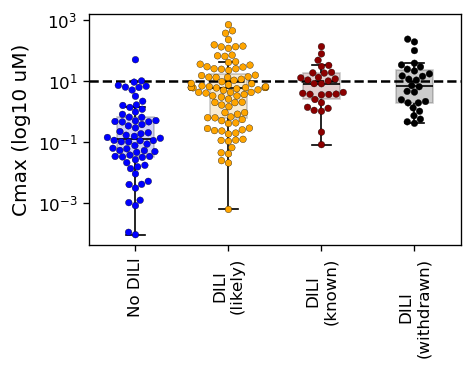

In [33]:
fig, ax = transparent_figure()

dmap.pl.boxplot_with_swarm(
    df_res_all,
    x='DILI_label',
    y='Cmax_uM',
    box_width=0.4,
    swarm_size=4,
    hue_order=['No DILI', 'DILI (likely)', 'DILI (known)', 'DILI (withdrawn)'],
    palette=['blue', 'orange', 'darkred', 'k'],
    axhline=10,
    ylabel='Cmax (log10 uM)',
    xlabel='',
    show_legend=False,
    show=False,
)
plt.xticks(rotation=90)
plt.yscale('log')
plt.show()

## 7. Roc curves

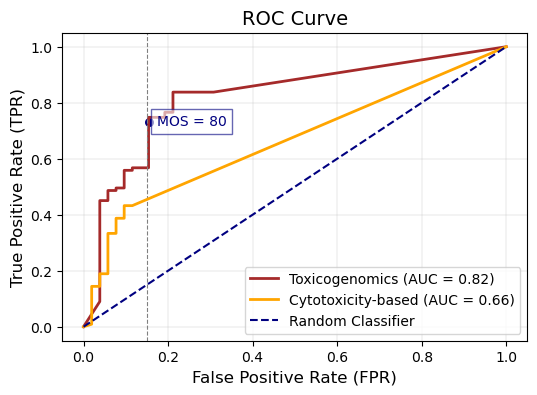

In [34]:
# Cross-validation

df_res_DILI = df_res_cv[
    df_res_cv['DILI_label'].isin(
        ['DILI (withdrawn)', 'DILI (known)', 'DILI (likely)', 'No DILI']
    )
]
y_true = ~df_res_DILI['DILI_label'].isin(['No DILI'])

plt.figure(figsize=(6, 4))
dmap.pl.roc_curve(
    y_true,
    df_res_DILI['MOS_ToxPredictor'],
    threshold_points=[80],
    axvline=0.15,
    threshold_name='MOS',
    label='Toxicogenomics',
    inverse=True,
    show=False,
)
dmap.pl.roc_curve(
    y_true,
    df_res_DILI['MOS_Cytotoxicity'],
    label='Cytotoxicity-based',
    color='orange',
    inverse=True,
    show=True,
)

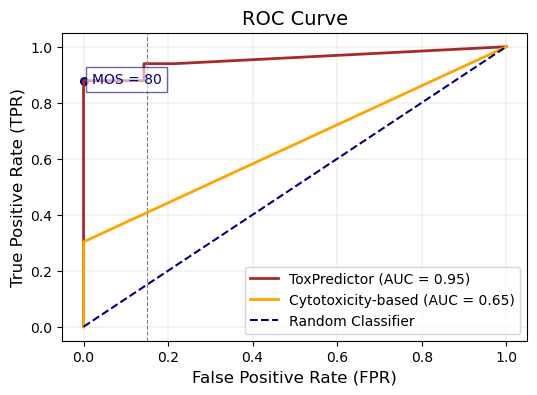

In [35]:
# Validation

df_res_DILI = df_res_val[
    df_res_val['DILI_label'].isin(
        ['DILI (withdrawn)', 'DILI (known)', 'DILI (likely)', 'No DILI']
    )
]
y_true = ~df_res_DILI['DILI_label'].isin(['No DILI'])

plt.figure(figsize=(6, 4))
dmap.pl.roc_curve(
    y_true,
    df_res_DILI['MOS_ToxPredictor'],
    threshold_points=[80],
    axvline=0.15,
    threshold_name='MOS',
    label='ToxPredictor',
    inverse=True,
    show=False,
)
dmap.pl.roc_curve(
    y_true,
    df_res_DILI['MOS_Cytotoxicity'],
    label='Cytotoxicity-based',
    color='orange',
    inverse=True,
    show=True,
)

## 8. Cox inhibitor examples

In [36]:
adata_all = dmap.datasets.DILImap_data()
df_adata_all = adata_all.to_df()

Package: s3://dilimap/public/data. Top hash: e5bf3de9d2
Package: s3://dilimap/public/data. Top hash: e5bf3de9d2


/opt/anaconda3/envs/py310/lib/python3.10/site-packages/anndata/_core/merge.py:1349: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  concat_annot = pd.concat(


In [37]:
cmpds = ['Valdecoxib', 'Sulindac', 'Lumiracoxib']
df_res_all.loc[cmpds]['MOS_ToxPredictor']

compound_name
Valdecoxib     300.000000
Sulindac        31.264035
Lumiracoxib      1.000000
Name: MOS_ToxPredictor, dtype: float64

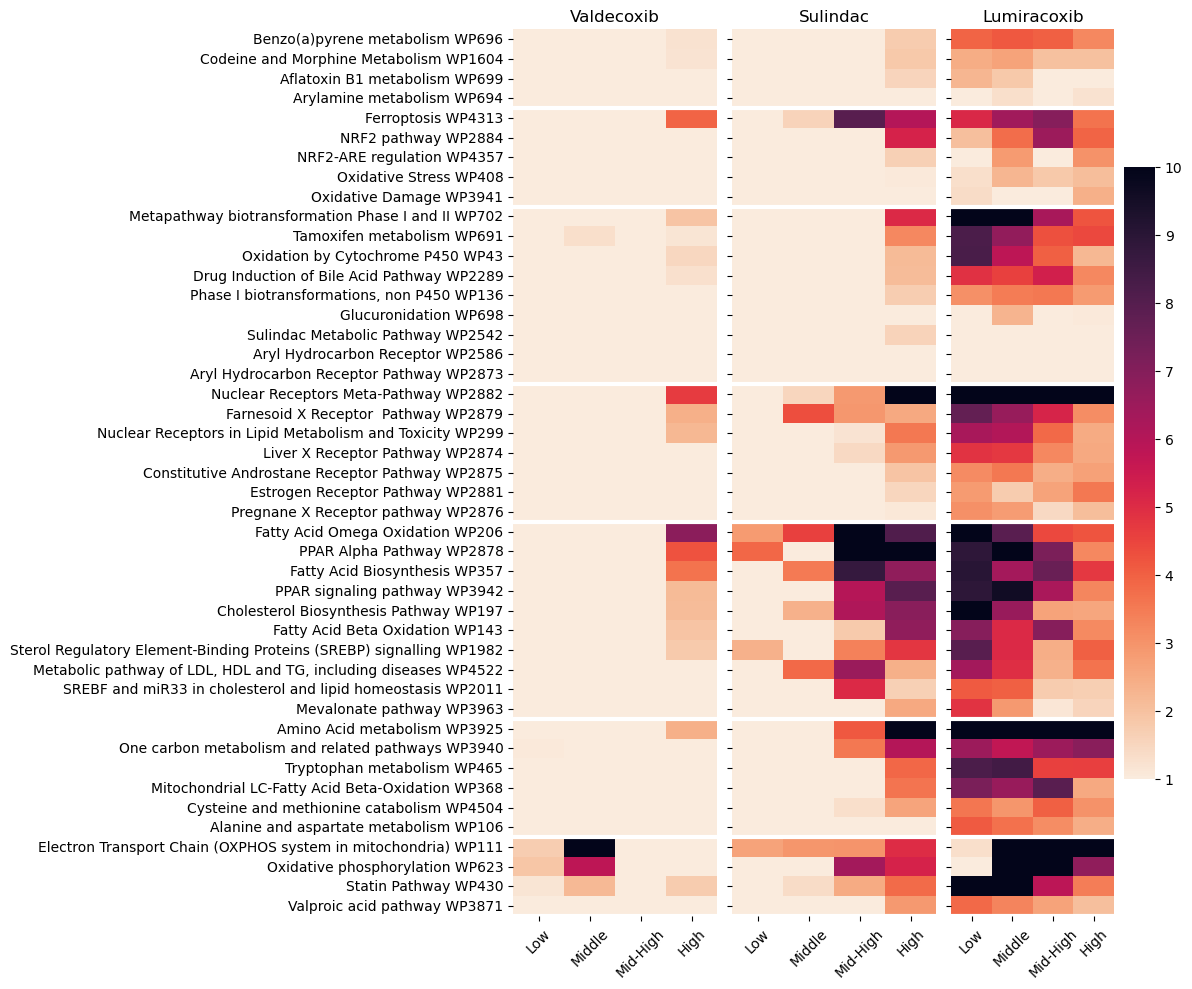

In [38]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(12, 10), sharey=True)

for i, cmpd in enumerate(cmpds):
    df_sub = df_adata_all.loc[cmpd]
    df_sub_sorted = df_sub[
        np.hstack(
            [
                (df_sub[pw].sum(0) + df_sub[pw].iloc[-1])
                .sort_values(ascending=False)
                .index
                for k, pw in model.DILI_pathways.items()
            ]
        )
    ]

    ax = axes[i]
    sns.heatmap(
        df_sub_sorted.T,
        ax=ax,
        cbar=(i == 2),
        cmap='rocket_r',
        vmin=1,
        vmax=10,
        yticklabels=True,
    )

    # Draw white lines between pathway groups
    hlines = np.cumsum(np.hstack([len(pw) for k, pw in model.DILI_pathways.items()]))
    ax.hlines(hlines, *ax.get_xlim(), colors='white', linewidth=3)

    ax.set_title(cmpd)
    ax.set_xticklabels(['Low', 'Middle', 'Mid-High', 'High'], rotation=45)

plt.tight_layout()
plt.show()

In [39]:
adata_all.obs['DILI_prob'] = model.predict(adata_all)
adata_all.obs['DILI_prob_std'] = model.predict_proba_across_estimators(adata_all).std(1)

283 out of 469 features in your data are not present in the training data. These features will not impact predictions. You can access the features available in the training data via `model.features`.
283 out of 469 features in your data are not present in the training data. These features will not impact predictions. You can access the features available in the training data via `model.features`.


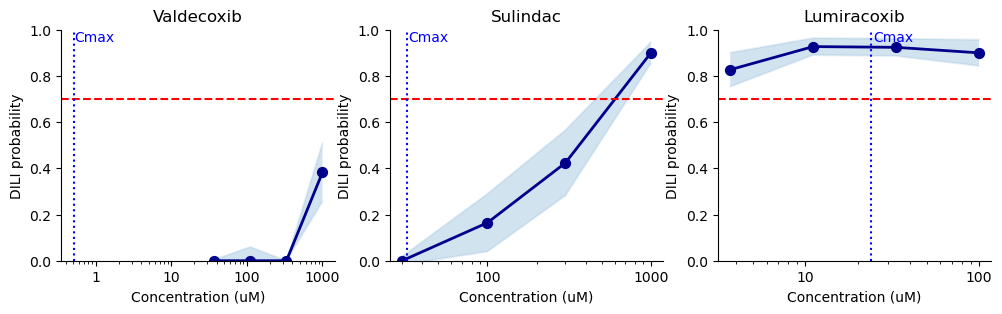

In [40]:
from matplotlib.ticker import FuncFormatter

fig, axs = plt.subplots(1, len(cmpds), figsize=(4 * len(cmpds), 3))

for i, cmpd in enumerate(cmpds):
    y_mean = adata_all[cmpd].obs['DILI_prob']
    y_std = adata_all[cmpd].obs['DILI_prob_std']

    error = y_std
    lower = y_mean - 2.576 * error
    upper = y_mean + 2.576 * error

    df = adata_all[cmpd].obs[['dose_uM', 'DILI_prob']]
    x = adata_all[cmpd].obs['dose_uM'].values

    axs[i].plot(x, lower, color='tab:blue', alpha=0.1)
    axs[i].plot(x, upper, color='tab:blue', alpha=0.1)
    axs[i].fill_between(x, lower, upper, alpha=0.2)

    axs[i].scatter(x, y_mean, color='darkblue', s=50)
    axs[i].plot(x, y_mean, label='DILI_prob', color='darkblue', linewidth=2)

    axs[i].set_xlabel('Concentration (uM)')
    axs[i].set_ylabel('DILI probability')
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)

    axs[i].axhline(0.7, linestyle='--', color='red')
    drug_cmax = adata_all[cmpd].obs['Cmax_uM'].iloc[0]
    if drug_cmax is not np.nan:
        axs[i].axvline(drug_cmax, linestyle=':', color='b')  #'-', '--', '-.',
        axs[i].annotate('Cmax', (drug_cmax * 1.02, 0.95), color='b')
    # axs[i].annotate('DILI cutoff', (np.min(x)*0.95, 0.72), c='red')

    axs[i].set_ylim(0, 1)
    axs[i].set_xscale('log')
    axs[i].set_title(cmpd)
    # ax.legend(loc='lower right')

    axs[i].xaxis.set_major_formatter(
        FuncFormatter(
            lambda x, pos: (
                '{{:.{:1d}f}}'.format(int(np.maximum(-np.log10(x), 0)))
            ).format(x)
        )
    )

plt.show()

## 9. DILI-associated pathways

In [41]:
df_features = model.feature_importances(dili_pathways=True)

In [42]:
df_features

,AUC,MDI,Pearson_r,Spearman_r
Aflatoxin B1 metabolism WP699,0.719395,0.006347,0.410378,0.527361
Arylamine metabolism WP694,0.751494,0.032419,0.554071,0.664373
Benzo(a)pyrene metabolism WP696,0.630856,0.000367,0.451629,0.577023
Codeine and Morphine Metabolism WP1604,0.612445,0.002123,0.325029,0.517206
Oxidative Stress WP408,0.710671,0.002062,0.615786,0.685112
Oxidative Damage WP3941,0.739204,0.006290,0.607092,0.768463
Ferroptosis WP4313,0.772460,0.004683,0.764697,0.804201
NRF2 pathway WP2884,0.700766,0.001497,0.655264,0.728464
NRF2-ARE regulation WP4357,0.710478,0.000591,0.579007,0.754713
Glucuronidation WP698,0.610782,0.003788,0.358567,0.469271


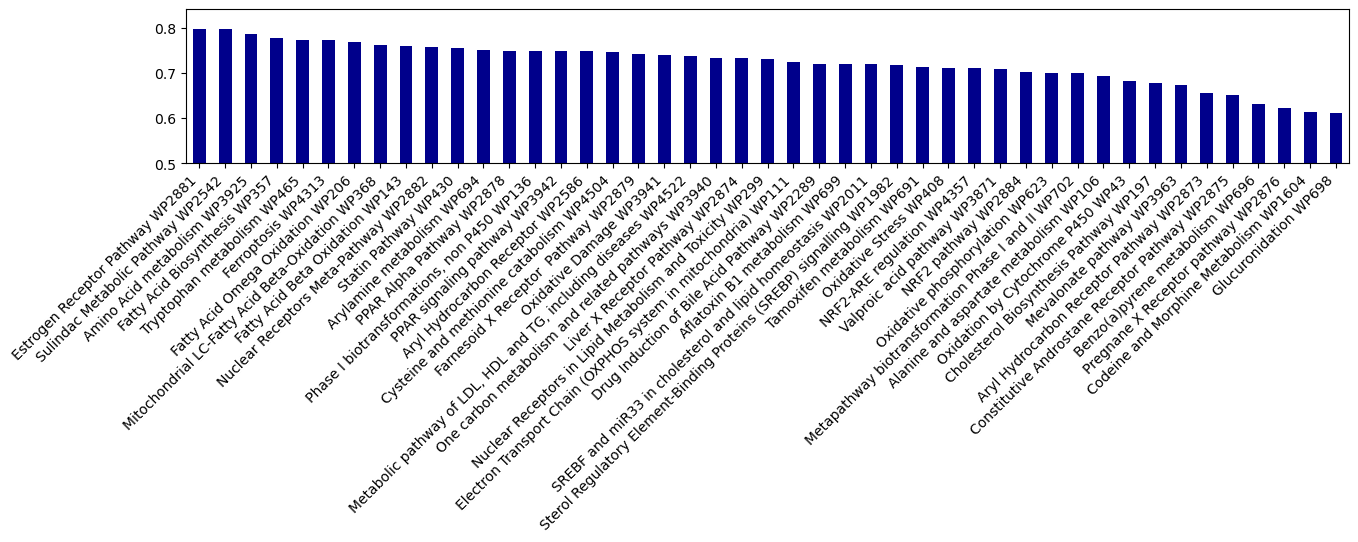

In [43]:
plt.figure(figsize=(15, 2))
df_features['AUC'].sort_values(ascending=False).plot.bar(color='darkblue')
plt.ylim(0.5, 0.84)  # also show non-DILI pathways
plt.xticks(rotation=45, ha='right');

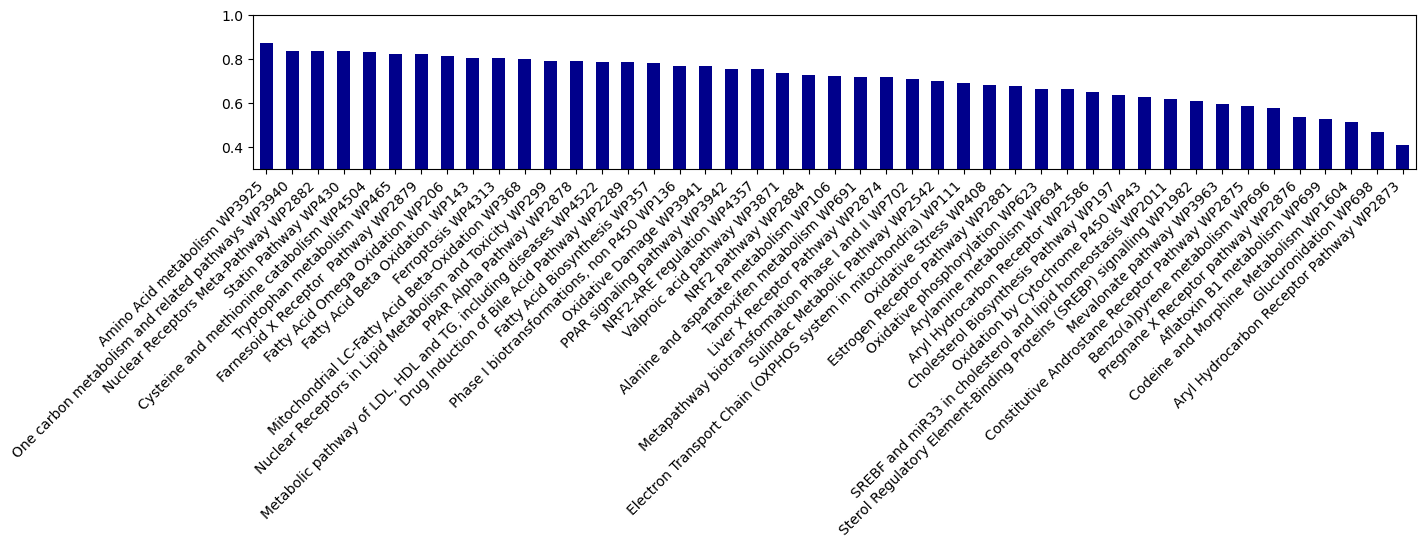

In [44]:
plt.figure(figsize=(15, 2))
df_features.sort_values('Spearman_r', ascending=False)['Spearman_r'].plot.bar(
    color='darkblue'
)
plt.ylim(0.3, 1)  # also show non-DILI pathways
plt.xticks(rotation=45, ha='right');

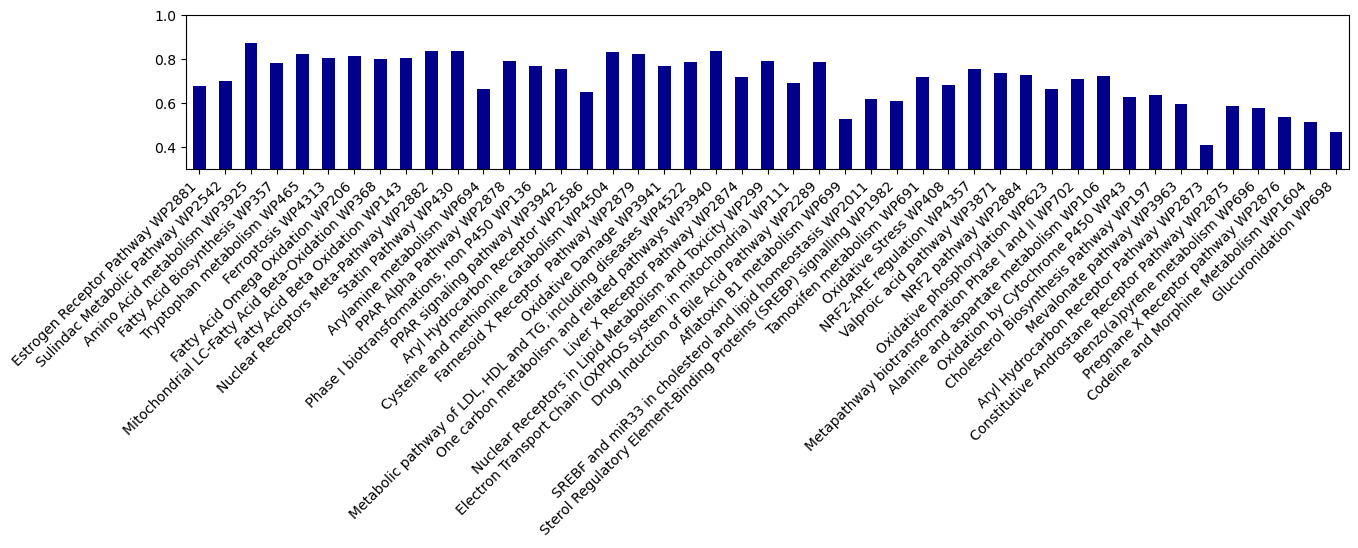

In [45]:
plt.figure(figsize=(15, 2))
df_features.sort_values('AUC', ascending=False)['Spearman_r'].plot.bar(color='darkblue')
plt.ylim(0.3, 1)  # also show non-DILI pathways
plt.xticks(rotation=45, ha='right');

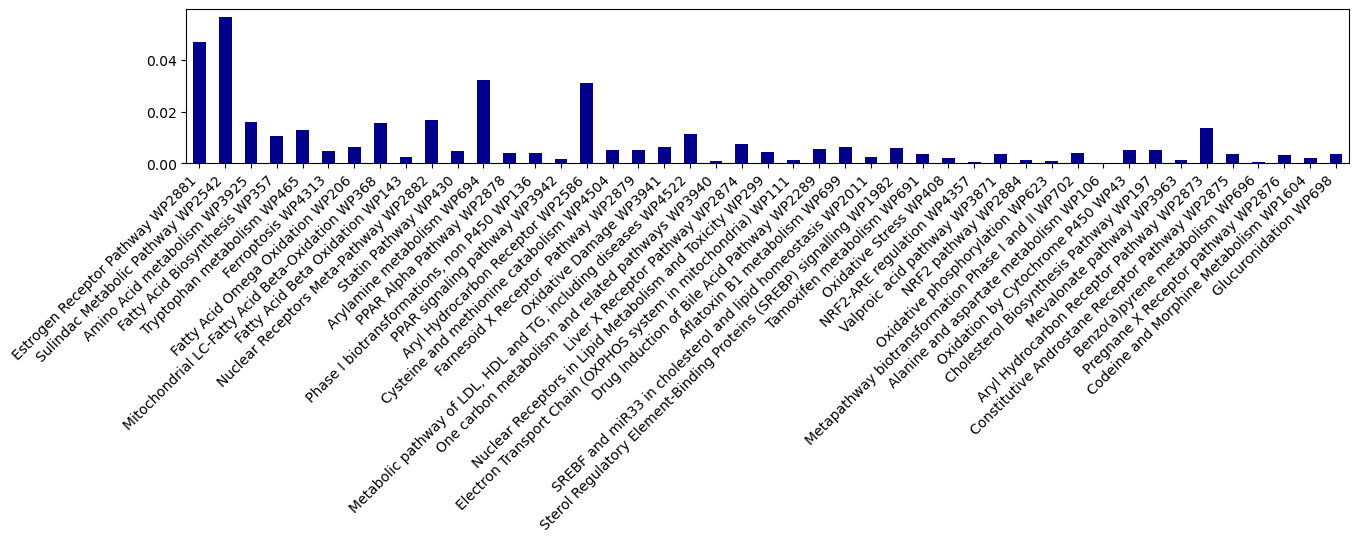

In [46]:
plt.figure(figsize=(15, 2))
df_features.sort_values('AUC', ascending=False)['MDI'].plot.bar(color='darkblue')
# plt.ylim(.5, .84)  # also show non-DILI pathways
plt.xticks(rotation=45, ha='right');

/opt/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(**tight_params)


Text(0.5, 1.0, 'DILI-Associated Pathways')

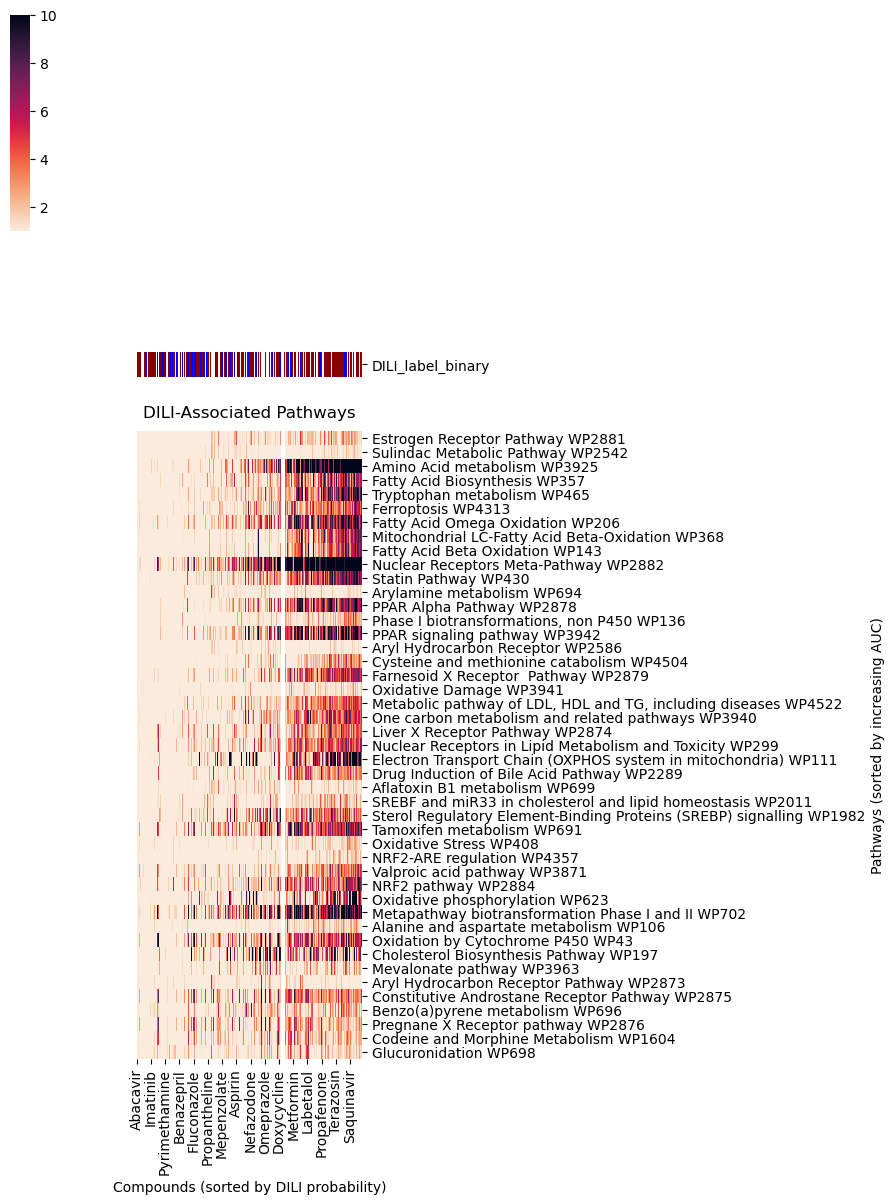

In [47]:
## Dose/cmpd-specific DILI annotations

pws = df_features['AUC'].sort_values().index
df_sub = adata_all.to_df()[pws]
df_sub = df_sub.iloc[np.argsort(adata_all.obs['DILI_prob'])]

col_colors = (
    adata_all[np.argsort(adata_all.obs['DILI_prob'])]
    .obs['DILI_label_binary']
    .map({'DILI': 'darkred', 'No DILI': 'blue', np.nan: 'snow'})
)

g = sns.clustermap(
    df_sub.T[::-1],
    col_cluster=False,
    row_cluster=False,
    yticklabels=True,
    cmap='rocket_r',
    vmin=1,
    vmax=10,
    figsize=(4, 12),
    col_colors=col_colors,
)
g.ax_heatmap.vlines(
    sum(adata_all.obs['DILI_prob'] < 0.7),
    colors='white',
    linewidth=3,
    *g.ax_heatmap.get_ylim(),
)

# Add title and axis labels
g.ax_heatmap.set_xlabel('Compounds (sorted by DILI probability)')
g.ax_heatmap.set_ylabel('Pathways (sorted by increasing AUC)')
g.ax_heatmap.set_title('DILI-Associated Pathways', fontsize=12, pad=10)

## 10. DILI-associated genes

In [172]:
adata_deseq = dmap.datasets.DILImap_training_data(level='deseq2')

Package: s3://dilimap/proprietary/data. Top hash: ede9d7c164


In [173]:
adata_all.obs['CMPD_DOSE'] = (
    adata_all.obs['compound_name'].astype(str)
    + '_'
    + adata_all.obs['dose_level'].astype(str)
)

In [174]:
mask = ~adata_all.obs_names.duplicated()

for k in ['DILI_label_binary', 'DILI_label', 'DILI_prob']:
    adata_deseq.obs[k] = adata_deseq.obs['CMPD_DOSE'].map(
        adata_all[mask].obs.set_index('CMPD_DOSE')[k]
    )

In [175]:
mask = ~adata_deseq.obs['DILI_label'].isna()

data_sub = adata_deseq[mask][
    adata_deseq[mask].obs['DILI_label'].str.startswith('DILI')
    & (adata_deseq[mask].obs['DILI_prob'] > 0.5)
].copy()

data_sub = data_sub[~data_sub.obs_names.duplicated(keep='first')].copy()

In [176]:
data_sub.var['n_de_up'] = (
    (data_sub.layers['FDR'] < 0.05) * (data_sub.layers['LFC'] > 0)
).sum(0)
data_sub.var['n_de_dn'] = (
    (data_sub.layers['FDR'] < 0.05) * (data_sub.layers['LFC'] < 0)
).sum(0)
data_sub.var['n_de_cm'] = data_sub.var[['n_de_up', 'n_de_dn']].max(1)

data_sub.var['n_de_up_adj'] = data_sub.var['n_de_up'] - data_sub.var['n_de_dn']
data_sub.var['n_de_dn_adj'] = data_sub.var['n_de_dn'] - data_sub.var['n_de_up']

df_up = data_sub.var.sort_values('n_de_up', ascending=False)[:50]
df_dn = data_sub.var.sort_values('n_de_dn', ascending=False)[:50]

/var/folders/lz/prv79nmj5msg8h6nzqn0w7cw0000gn/T/ipykernel_1362/170882548.py:2: RuntimeWarning: divide by zero encountered in log10
  adata_deseq.layers['DES'] = -np.log10(adata_deseq.layers['FDR']) * np.sign(adata_deseq.layers['LFC'])


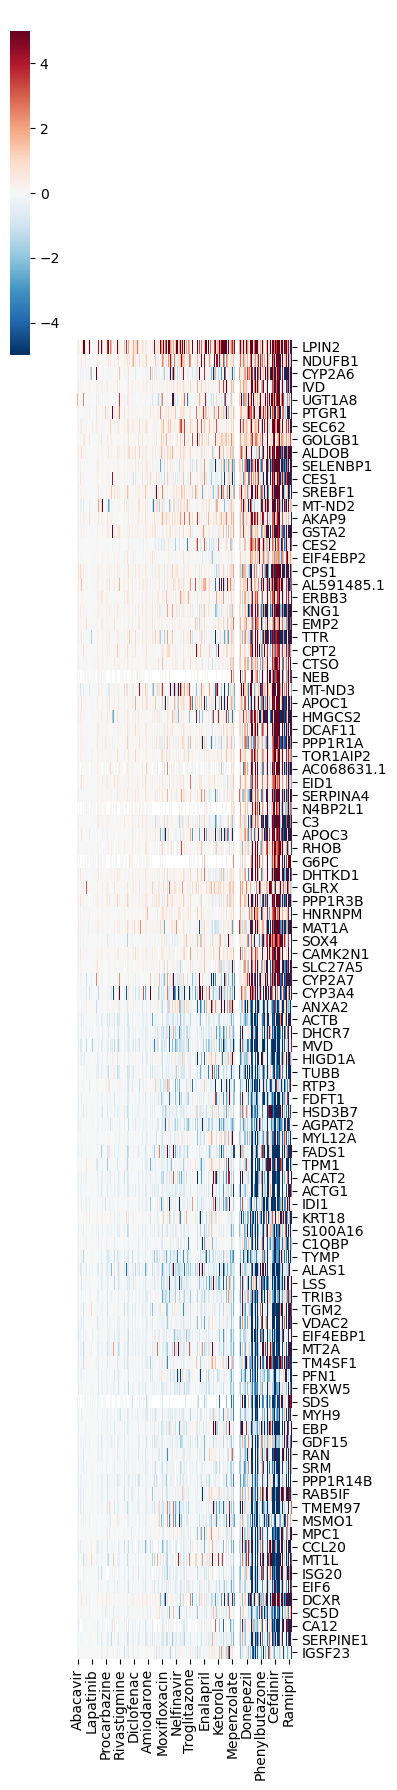

In [177]:
## Dose/cmpd-specific DILI annotations
adata_deseq.layers['DES'] = -np.log10(adata_deseq.layers['FDR']) * np.sign(
    adata_deseq.layers['LFC']
)

mask = ~adata_deseq.obs['DILI_label'].isna()

genes = list(df_dn.index[::-1]) + list(df_up.index[::-1])
df_sub = adata_deseq[mask].to_df('DES')[genes]
df_sub = df_sub.iloc[np.argsort(adata_deseq[mask].obs['DILI_prob'])]

g = sns.clustermap(
    df_sub.T[::-1],
    col_cluster=False,
    row_cluster=False,
    yticklabels=True,
    cmap='RdBu_r',
    vmin=-5,
    vmax=5,
    figsize=(4, 18),  # cbar=False
)
g.ax_heatmap.vlines(
    sum(adata_deseq[mask].obs['DILI_prob'] < 0.5),
    colors='white',
    linewidth=3,
    *g.ax_heatmap.get_ylim(),
)

## Push results to S3

In [33]:
# dmap.s3.write(df_res_all, 'ToxPredictor_results.csv')

Package: s3://dilimap/public/data. Top hash: f8d8274caa


Copying objects: 100%|█████████████████████| 41.0k/41.0k [00:01<00:00, 33.5kB/s]


Package public/data@d3f7082 pushed to s3://dilimap
Run `quilt3 catalog s3://dilimap/` to browse.
Successfully pushed the new package
